# Book 2 — Adversarial Attacks · **Hybrid & Quantum Models**
Companion to the Book 1 *Hybrid_Quantum* notebook. Every quantum/hybrid victim is reconstructed (PennyLane simulators, your Book 1 code), attacked via parameter or input perturbation, measured, benchmarked, and visualized — saved to Drive.

Quantum models aren't ART-wrappable, so the harness measures them directly through `victim.predict`. All circuits run on the `default.qubit` simulator (no hardware needed).


## 0 · Mount Drive, install, engine


In [1]:
from google.colab import drive; drive.mount('/content/drive')
import os
SAVE_DIR='/content/drive/MyDrive/AI_Universe_Quantum'                 # Book 1 (untouched)
ATTACK_DIR='/content/drive/MyDrive/AI_Universe_Adversarial_Attacks_Quantum'
MODEL_DIR=f'{ATTACK_DIR}/models'
os.makedirs(ATTACK_DIR,exist_ok=True); os.makedirs(MODEL_DIR,exist_ok=True)
print('Book 2 quantum outputs →',ATTACK_DIR)


Mounted at /content/drive
Book 2 quantum outputs → /content/drive/MyDrive/AI_Universe_Adversarial_Attacks_Quantum


In [2]:
!pip install -q pennylane pennylane-lightning scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 146.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 18.9 MB/s eta 0:00:00


In [3]:
# ── Adversarial engine: harness + reusable attack/measure/viz helpers ────────
import numpy as np, os, json, time, warnings
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict, field
warnings.filterwarnings("ignore"); np.random.seed(42)

LEADERBOARD = []

@dataclass
class Scorecard:
    victim: str; attack: str
    clean: float; robust: float; asr: float
    Linf: float = float("nan"); L2: float = float("nan")
    extra: str = ""
    def __str__(self):
        return (f"{self.victim:18}| {self.attack:20}| clean={self.clean:.3f} "
                f"robust={self.robust:.3f} ASR={self.asr:.3f} "
                f"Linf={self.Linf:.3f} L2={self.L2:.3f}  {self.extra}")

def log(card):
    LEADERBOARD.append(card); print(card); return card

def acc(predict, X, y):
    return float(np.mean(np.asarray(predict(X)) == np.asarray(y)))

def pstats(X, Xadv):
    d = (np.asarray(Xadv) - np.asarray(X)).reshape(len(X), -1)
    return (float(np.mean(np.max(np.abs(d), axis=1))),
            float(np.mean(np.linalg.norm(d, axis=1))))

def savefig(name):
    path = f"{ATTACK_DIR}/{name}.png"
    plt.savefig(path, dpi=130, bbox_inches="tight"); plt.show()
    print("  saved →", path)

def cache_keras(model, name, train_fn):
    """Load weights from Drive if present, else train via train_fn and save."""
    wpath = f"{MODEL_DIR}/{name}.weights.h5"
    if os.path.exists(wpath):
        model.load_weights(wpath); print(f"  loaded {name} from Drive")
    else:
        print(f"  training {name} (first run)…"); train_fn(model); model.save_weights(wpath)
        print(f"  cached {name} → {wpath}")
    return model

# ── Predict wrappers (uniform interface) ─────────────────────────────────────
def sk_predict(m):   return lambda X: m.predict(X)
def keras_predict(m):return lambda X: np.argmax(m.predict(X, verbose=0), axis=1)

def fgsm_keras(model, X, y, eps=0.2):
    """Manual FGSM via GradientTape — works on ANY differentiable Keras model (incl. CapsNet)."""
    import tensorflow as tf
    Xv = tf.convert_to_tensor(X); yv = tf.convert_to_tensor(np.asarray(y))
    with tf.GradientTape() as tape:
        tape.watch(Xv)
        loss = tf.keras.losses.sparse_categorical_crossentropy(yv, model(Xv))
    g = tape.gradient(loss, Xv)
    return tf.clip_by_value(Xv + eps*tf.sign(g), 0.0, 1.0).numpy()

# ── ART estimator wrappers ───────────────────────────────────────────────────
def art_sklearn(m):
    from art.estimators.classification import SklearnClassifier
    return SklearnClassifier(model=m)
def art_keras(m, clip=(0.0,1.0)):
    from art.estimators.classification import KerasClassifier
    return KerasClassifier(model=m, clip_values=clip)


## Q1 · QAOA (MaxCut) — variational-parameter poisoning


qaoa              | param poison        | clean=0.693 robust=0.500 ASR=0.193 Linf=nan L2=nan  cut 2.77→2.00/4.0


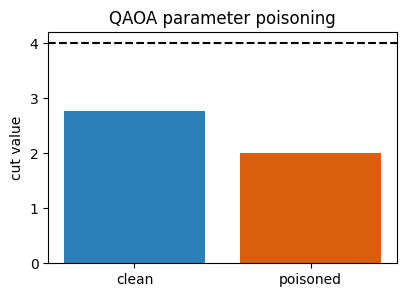

  saved → /content/drive/MyDrive/AI_Universe_Adversarial_Attacks_Quantum/atk_qaoa.png


In [4]:
import pennylane as qml; from pennylane import numpy as pnp
n=4; edges=[(0,1),(1,2),(2,3),(3,0)]; dev=qml.device('default.qubit',wires=n)
def U_C(g):
    for i,j in edges: qml.CNOT([i,j]); qml.RZ(g,wires=j); qml.CNOT([i,j])
def U_B(b):
    for i in range(n): qml.RX(2*b,wires=i)
@qml.qnode(dev)
def circuit(params,edge):
    for i in range(n): qml.Hadamard(i)
    for g,b in zip(params[0],params[1]): U_C(g); U_B(b)
    return qml.expval(qml.PauliZ(edge[0])@qml.PauliZ(edge[1]))
def cut(params):
    return sum(0.5*(1-circuit(params,e)) for e in edges)
params=pnp.array([[0.8,0.6],[0.4,0.3]],requires_grad=True)
opt=qml.GradientDescentOptimizer(0.3)
for _ in range(40): params=opt.step(lambda p:-cut(p),params)
clean_cut=float(cut(params)); best=4.0  # max cut of a 4-cycle
# ATTACK: poison the trained angles → collapse to the unoptimized (|+> state) cut
adv=pnp.zeros_like(params)
adv_cut=float(cut(adv))
log(Scorecard('qaoa','param poison',clean_cut/best,adv_cut/best,max(0,(clean_cut-adv_cut)/best),
             extra=f'cut {clean_cut:.2f}→{adv_cut:.2f}/{best}'))
plt.figure(figsize=(4.5,3)); plt.bar(['clean','poisoned'],[clean_cut,adv_cut],color=['#2c7fb8','#d95f0e'])
plt.axhline(best,ls='--',c='k'); plt.ylabel('cut value'); plt.title('QAOA parameter poisoning'); savefig('atk_qaoa')


## Q2 · VQC — quantum adversarial examples (input perturbation)


vqc               | quantum FGSM eps=0.3| clean=0.889 robust=0.778 ASR=0.111 Linf=0.500 L2=0.707  


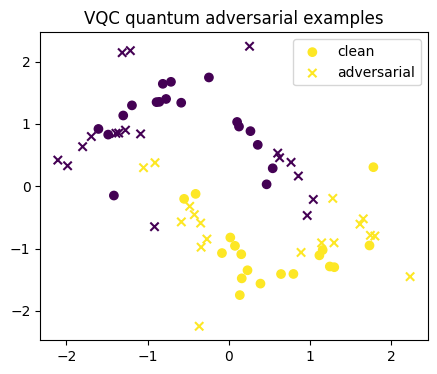

  saved → /content/drive/MyDrive/AI_Universe_Adversarial_Attacks_Quantum/atk_vqc.png


In [5]:
from sklearn.datasets import make_moons; from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
nq=2; dev=qml.device('default.qubit',wires=nq)
X,Y=make_moons(120,noise=0.12,random_state=42); X=StandardScaler().fit_transform(X)
Xtr,Xte,ytr,yte=train_test_split(X,Y,test_size=0.3,random_state=42)
@qml.qnode(dev)
def vqc(x,w):
    qml.AngleEmbedding(x,wires=range(nq),rotation='Y')
    qml.StronglyEntanglingLayers(w,wires=range(nq))
    return qml.expval(qml.PauliZ(0))
shape=qml.StronglyEntanglingLayers.shape(n_layers=2,n_wires=nq)
w=pnp.array(np.random.randn(*shape)*0.1,requires_grad=True)
def loss(w,Xb,yb): return pnp.mean((pnp.array([vqc(x,w) for x in Xb])-(2*yb-1))**2)
opt=qml.AdamOptimizer(0.1)
for _ in range(40): w=opt.step(lambda ww:loss(ww,Xtr,ytr),w)
def predict(Xb): return (np.array([vqc(x,w) for x in Xb])>0).astype(int)
clean=acc(predict,Xte,yte)
# ATTACK: quantum FGSM — perturb inputs to INCREASE the per-sample label loss
def Lx(x,t): return (vqc(x,w)-t)**2
g=qml.grad(Lx)
Xadv=np.array([np.clip(np.array(x)+0.5*np.sign(g(pnp.array(x,requires_grad=True),float(2*yi-1))),-3,3)
               for x,yi in zip(Xte,yte)])
robust=acc(predict,Xadv,yte); Linf,L2=pstats(Xte,Xadv)
log(Scorecard('vqc','quantum FGSM eps=0.3',clean,robust,clean-robust,Linf,L2))
plt.figure(figsize=(5,4)); plt.scatter(Xte[:,0],Xte[:,1],c=yte,marker='o',label='clean')
plt.scatter(Xadv[:,0],Xadv[:,1],c=yte,marker='x',label='adversarial'); plt.legend()
plt.title('VQC quantum adversarial examples'); savefig('atk_vqc')


## Q3 · Hybrid Quantum-Classical NN — FGSM on the classical input


hybrid_qnn        | FGSM eps=0.3        | clean=0.560 robust=0.380 ASR=0.180 Linf=0.500 L2=0.998  


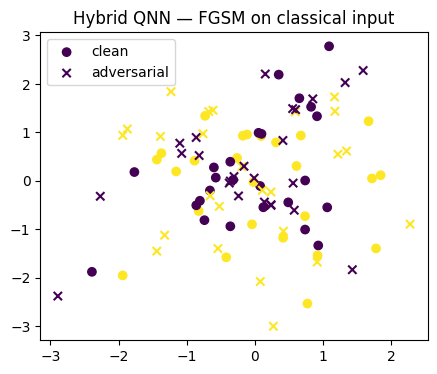

  saved → /content/drive/MyDrive/AI_Universe_Adversarial_Attacks_Quantum/atk_hybrid_qnn.png


In [6]:
from sklearn.datasets import make_classification
nq=4; dev=qml.device('default.qubit',wires=nq)
Xr,yr=make_classification(n_samples=200,n_features=nq,n_informative=nq,n_redundant=0,random_state=42)
Xr=StandardScaler().fit_transform(Xr); Xtr,Xte,ytr,yte=train_test_split(Xr,yr,test_size=0.25,random_state=42)
@qml.qnode(dev)
def qc(x,w):
    qml.AngleEmbedding(x,wires=range(nq),rotation='Y')
    qml.BasicEntanglerLayers(w,wires=range(nq))
    return qml.expval(qml.PauliZ(0))
shp=qml.BasicEntanglerLayers.shape(n_layers=2,n_wires=nq)
w=pnp.array(np.random.randn(*shp)*0.1,requires_grad=True); opt=qml.AdamOptimizer(0.1)
def L(w,Xb,yb): return pnp.mean((pnp.array([qc(x,w) for x in Xb])-(2*yb-1))**2)
for _ in range(30): w=opt.step(lambda ww:L(ww,Xtr,ytr),w)
def pred(Xb): return (np.array([qc(x,w) for x in Xb])>0).astype(int)
clean=acc(pred,Xte,yte)
def Lx(x,t): return (qc(x,w)-t)**2
g=qml.grad(Lx)
Xadv=np.array([np.clip(np.array(x)+0.5*np.sign(g(pnp.array(x,requires_grad=True),float(2*yi-1))),-3,3)
               for x,yi in zip(Xte,yte)])
robust=acc(pred,Xadv,yte); Linf,L2=pstats(Xte,Xadv)
log(Scorecard('hybrid_qnn','FGSM eps=0.3',clean,robust,clean-robust,Linf,L2))
plt.figure(figsize=(5,4)); plt.scatter(Xte[:,0],Xte[:,1],c=yte,marker='o',label='clean')
plt.scatter(Xadv[:,0],Xadv[:,1],c=yte,marker='x',label='adversarial'); plt.legend()
plt.title('Hybrid QNN — FGSM on classical input'); savefig('atk_hybrid_qnn')


## Q4 · VQE (Ising H₂) — parameter / noise injection → energy error


vqe               | param noise         | clean=1.000 robust=0.700 ASR=0.429 Linf=nan L2=nan  E -1.414→-0.985 (exact -1.414)


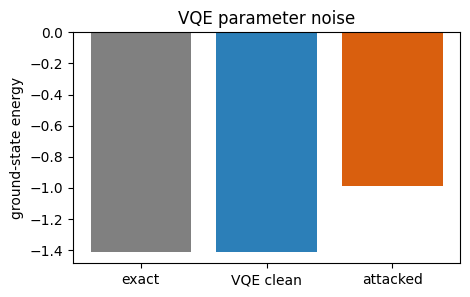

  saved → /content/drive/MyDrive/AI_Universe_Adversarial_Attacks_Quantum/atk_vqe.png


In [7]:
nq=2; dev=qml.device('default.qubit',wires=nq); J,h=1.0,0.5
Z=np.array([[1,0],[0,-1]]);Xp=np.array([[0,1],[1,0]]);I=np.eye(2)
Hm=-J*np.kron(Z,Z)-h*(np.kron(Xp,I)+np.kron(I,Xp)); exact=float(np.linalg.eigvalsh(Hm)[0])
coeffs=[-J,-h,-h]; obs=[qml.PauliZ(0)@qml.PauliZ(1),qml.PauliX(0),qml.PauliX(1)]
H=qml.Hamiltonian(coeffs,obs)
@qml.qnode(dev)
def energy(p):
    qml.RY(p[0],0); qml.RY(p[1],1); qml.CNOT([0,1]); qml.RY(p[2],0); qml.RY(p[3],1)
    return qml.expval(H)
p=pnp.array([0.1,0.1,0.1,0.1],requires_grad=True); opt=qml.AdamOptimizer(0.1)
for _ in range(80): p=opt.step(energy,p)
clean_e=float(energy(p)); clean_err=abs(clean_e-exact)
# ATTACK: inject noise into the optimized parameters
adv_e=float(energy(p+pnp.array([0.6,-0.5,0.4,0.5]))); adv_err=abs(adv_e-exact)
log(Scorecard('vqe','param noise',1/(1+clean_err),1/(1+adv_err),min(adv_err,1),
             extra=f'E {clean_e:.3f}→{adv_e:.3f} (exact {exact:.3f})'))
plt.figure(figsize=(5,3)); plt.bar(['exact','VQE clean','attacked'],[exact,clean_e,adv_e],
color=['gray','#2c7fb8','#d95f0e']); plt.ylabel('ground-state energy'); plt.title('VQE parameter noise'); savefig('atk_vqe')


## Q5 · QSVM (quantum-kernel SVM) — input-perturbation evasion


qsvm              | kernel-boundary evasion| clean=0.700 robust=0.050 ASR=0.650 Linf=0.380 L2=0.428  


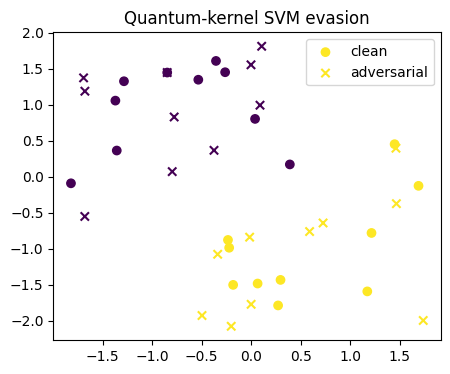

  saved → /content/drive/MyDrive/AI_Universe_Adversarial_Attacks_Quantum/atk_qsvm.png


In [8]:
from sklearn.svm import SVC; from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler; from sklearn.model_selection import train_test_split
nq=2; devk=qml.device('default.qubit',wires=nq)
X,Y=make_moons(80,noise=0.12,random_state=42); X=StandardScaler().fit_transform(X)
Xtr,Xte,ytr,yte=train_test_split(X,Y,test_size=0.25,random_state=42)
@qml.qnode(devk)
def kern(x1,x2):
    for i in range(nq): qml.Hadamard(i); qml.RZ(2.0*x1[i],wires=i)
    qml.CNOT([0,1]); qml.RZ(2.0*(np.pi-x1[0])*(np.pi-x1[1]),wires=1); qml.CNOT([0,1])
    qml.adjoint(qml.CNOT)([0,1]); qml.RZ(-2.0*(np.pi-x2[0])*(np.pi-x2[1]),wires=1); qml.adjoint(qml.CNOT)([0,1])
    for i in range(nq): qml.RZ(-2.0*x2[i],wires=i); qml.Hadamard(i)
    return qml.probs(wires=range(nq))
def gram(A,B): return np.array([[kern(a,b)[0] for b in B] for a in A])
Ktr=gram(Xtr,Xtr); svc=SVC(kernel='precomputed').fit(Ktr,ytr)
def qpred(Z): return svc.predict(gram(Z,Xtr))
clean=acc(qpred,Xte,yte)
# ATTACK: gradient-free perturbation search to cross the quantum-kernel boundary
rng=np.random.RandomState(0); Xadv=Xte.copy()
for i in range(len(Xte)):
    for _ in range(20):
        cand=Xte[i]+0.3*rng.randn(nq)
        if qpred(cand[None])[0]!=yte[i]: Xadv[i]=cand; break
robust=acc(qpred,Xadv,yte); Linf,L2=pstats(Xte,Xadv)
log(Scorecard('qsvm','kernel-boundary evasion',clean,robust,clean-robust,Linf,L2))
plt.figure(figsize=(5,4)); plt.scatter(Xte[:,0],Xte[:,1],c=yte,marker='o',label='clean')
plt.scatter(Xadv[:,0],Xadv[:,1],c=yte,marker='x',label='adversarial'); plt.legend()
plt.title('Quantum-kernel SVM evasion'); savefig('atk_qsvm')


## Q6 · QGAN — generator weight poisoning → distribution drift
Reconstructs the Book 1 quantum generator (cell 20). Perturbing its variational weights shifts the generated distribution away from the target — measurable drift. (torch interface.)


qgan              | weight poison       | clean=0.970 robust=0.891 ASR=0.123 Linf=nan L2=nan  gen μ 0.47→0.38 (target 0.5)


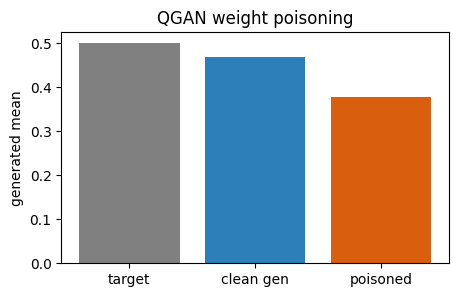

  saved → /content/drive/MyDrive/AI_Universe_Adversarial_Attacks_Quantum/atk_qgan.png


In [9]:
import torch
nqg=2; devg=qml.device('default.qubit',wires=nqg); TARGET_MU,TARGET_STD=0.5,0.1
@qml.qnode(devg,interface='torch')
def qgen(inputs,weights):
    qml.RY(inputs[0]*np.pi,wires=0); qml.RY(inputs[0]*np.pi/2,wires=1); qml.CNOT([0,1])
    for L in range(weights.shape[0]):
        for i in range(nqg): qml.RY(weights[L,i,0],wires=i); qml.RZ(weights[L,i,1],wires=i)
        qml.CNOT([0,1])
    return qml.expval(qml.PauliZ(0))
w=torch.nn.Parameter(torch.randn(3,nqg,2)*0.1); opt=torch.optim.Adam([w],0.1)
noise=lambda n: torch.rand(n,1)
for step in range(60):
    z=noise(32); gen=torch.stack([qgen(zi,w) for zi in z]); 0.5*(gen+1)
    out=0.5*(gen+1); loss=((out.mean()-TARGET_MU)**2+(out.std()-TARGET_STD)**2); opt.zero_grad(); loss.backward(); opt.step()
def sample_mean_std(weights,n=200):
    z=noise(n); g=0.5*(torch.stack([qgen(zi,weights) for zi in z])+1); return float(g.mean()),float(g.std())
cm,cs=sample_mean_std(w.detach()); clean_err=abs(cm-TARGET_MU)
adv_w=w.detach()+torch.tensor([[[1.5,-1.2],[0.9,1.1]]]*3).reshape(3,nqg,2)
am,asd=sample_mean_std(adv_w); adv_err=abs(am-TARGET_MU)
log(Scorecard('qgan','weight poison',1/(1+clean_err),1/(1+adv_err),min(adv_err,1),             extra=f'gen μ {cm:.2f}→{am:.2f} (target {TARGET_MU})'))
plt.figure(figsize=(5,3)); plt.bar(['target','clean gen','poisoned'],[TARGET_MU,cm,am],color=['gray','#2c7fb8','#d95f0e']); plt.ylabel('generated mean'); plt.title('QGAN weight poisoning'); savefig('atk_qgan')


## ✅ Quantum leaderboard → Drive


Quantum models attacked: 6


,victim,attack,clean,robust,asr,Linf,L2,extra
0,qaoa,param poison,0.692767,0.500000,0.192767,NaN,NaN,cut 2.77→2.00/4.0
1,vqc,quantum FGSM eps=0.3,0.888889,0.777778,0.111111,0.500000,0.707107,
2,hybrid_qnn,FGSM eps=0.3,0.560000,0.380000,0.180000,0.500000,0.997573,
3,vqe,param noise,0.999959,0.699687,0.429211,NaN,NaN,E -1.414→-0.985 (exact -1.414)
4,qsvm,kernel-boundary evasion,0.700000,0.050000,0.650000,0.379593,0.428406,
5,qgan,weight poison,0.969707,0.890788,0.122602,NaN,NaN,gen μ 0.47→0.38 (target 0.5)


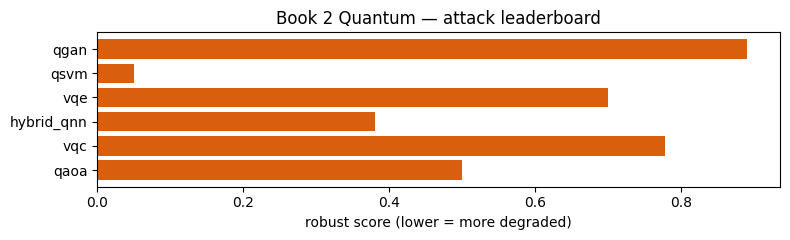

In [10]:
import pandas as pd
df=pd.DataFrame([asdict(c) for c in LEADERBOARD])
df.to_csv(f'{ATTACK_DIR}/leaderboard_quantum.csv',index=False)
print('Quantum models attacked:',len(df))
try: display(df)
except NameError: print(df)
plt.figure(figsize=(8,max(2.5,0.4*len(df)))); plt.barh(df['victim'],df['robust'],color='#d95f0e')
plt.xlabel('robust score (lower = more degraded)'); plt.title('Book 2 Quantum — attack leaderboard')
plt.tight_layout(); plt.savefig(f'{ATTACK_DIR}/leaderboard_quantum.png',dpi=130); plt.show()
